Alright let's try this on my stupid Kaggle dataset

In [4]:
# IMPORTS

# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Had to add this to test the model
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

import os
import sys
import kagglehub


# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-02 14:02:48 | INFO | M05 | === RUN START ===
2026-08-02 14:02:48 | INFO | M05 | project=M05
2026-08-02 14:02:48 | INFO | M05 | repo_dir=ml-05-ensembles
2026-08-02 14:02:48 | INFO | M05 | python=3.14.6
2026-08-02 14:02:48 | INFO | M05 | os=Windows 11
2026-08-02 14:02:48 | INFO | M05 | shell=powershell
2026-08-02 14:02:48 | INFO | M05 | cwd=notebooks
2026-08-02 14:02:48 | INFO | M05 | github_actions=False
2026-08-02 14:02:48 | INFO | M05 | Confirming installation:
2026-08-02 14:02:48 | INFO | M05 |   python:       3.14.6
2026-08-02 14:02:48 | INFO | M05 |   pandas:       3.0.3
2026-08-02 14:02:48 | INFO | M05 |   numpy:        2.5.0
2026-08-02 14:02:48 | INFO | M05 |   scikit-learn: 1.9.0
2026-08-02 14:02:48 | INFO | M05 |   seaborn:      0.13.2
2026-08-02 14:02:48 | INFO | M05 |   matplotlib:   3.11.0


In [5]:
# Download dataset and load CSV
path = kagglehub.dataset_download("anirudhchauhan/retail-store-inventory-forecasting-dataset")
df = pd.read_csv(f"{path}/retail_store_inventory.csv")

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 73100 rows, 15 columns


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


Awesome we have ourselves a data frame let me choose a thing to predict - I am going to try the worst possible idea and predict the "Weather Condition" based on ALL COLUMNS EXCEPT "Seasonality", "Date",  "Store ID", and "Region" because that's boring. It gives too much away! Alright let us take that last code block to prepare our data set and put what we need in.

In [16]:
# === Section 2. Load and Prepare the Data ===

LOG.info(f"Using loaded inventory dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# 1. Target for classification
TARGET_COL: Final[str] = "Weather Condition"

# 2. Categorical features to one-hot encode
# Excluded 'Product ID' to prevent high-cardinality overfitting
CATEGORICAL_COLS: list[str] = ["Category", "Region", "Seasonality"]

# 3. Base numerical features
NUMERICAL_COLS: list[str] = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing",
]

# All required features before one-hot encoding
RAW_FEATURE_COLS: list[str] = CATEGORICAL_COLS + NUMERICAL_COLS

# 4. Clean missing values across ALL required features and the target
required: list[str] = [TARGET_COL, *RAW_FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

# 5. One-hot encode categorical features
df_model = pd.get_dummies(df_model, columns=CATEGORICAL_COLS, drop_first=True)

# 6. Dynamically build final FEATURE_COLS list for training
FEATURE_COLS: list[str] = [
    col for col in df_model.columns 
    if col != TARGET_COL and col not in ["Store ID", "Product ID", "Date"]
]

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Features count: {len(FEATURE_COLS)}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-08-02 14:17:06 | INFO | M05 | Using loaded inventory dataset: 73100 rows, 15 columns
2026-08-02 14:17:06 | INFO | M05 | Original rows: 73100
2026-08-02 14:17:06 | INFO | M05 | Model rows:    73100
2026-08-02 14:17:06 | INFO | M05 | Features count: 18
2026-08-02 14:17:06 | INFO | M05 | Classes in target 'Weather Condition': ['Cloudy', 'Rainy', 'Snowy', 'Sunny']
2026-08-02 14:17:06 | DEBUG | M05 | Class counts:
Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64


Alright time to split and train the dataset

In [17]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""

# Extract features and multi-class target directly
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

# Perform stratified split directly on categorical text target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-02 14:17:09 | INFO | M05 | Train instances: 58480
2026-08-02 14:17:09 | INFO | M05 | Test instances: 14620


Fitting the ensemble models

In [18]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

# Baseline: A decision tree with default/moderate depth for multi-class baseline
modelA = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("   fitted: single_tree")

# Bagging Ensemble: Random Forest allowed slightly deeper growth to capture complex feature interactions
modelB = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    min_samples_leaf=2, 
    random_state=RANDOM_STATE
)
modelB.fit(X_train, y_train)
LOG.debug("   fitted: random_forest")

# Boosting Ensemble: Gradient Boosting adapted for multi-class log-loss
modelC = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
modelC.fit(X_train, y_train)
LOG.debug("   fitted: gradient_boosting")

2026-08-02 14:17:11 | INFO | M05 | Fitting single tree + two ensembles
2026-08-02 14:17:11 | DEBUG | M05 |    fitted: single_tree
2026-08-02 14:17:21 | DEBUG | M05 |    fitted: random_forest
2026-08-02 14:17:51 | DEBUG | M05 |    fitted: gradient_boosting


Now time to evaluate the trees

2026-08-02 14:18:29 | INFO | M05 |   single_tree        | Acc: 0.253 | AUC: 0.503 | F1: 0.193
2026-08-02 14:18:29 | INFO | M05 |   random_forest      | Acc: 0.250 | AUC: 0.498 | F1: 0.250
2026-08-02 14:18:29 | INFO | M05 |   gradient_boosting  | Acc: 0.245 | AUC: 0.498 | F1: 0.245


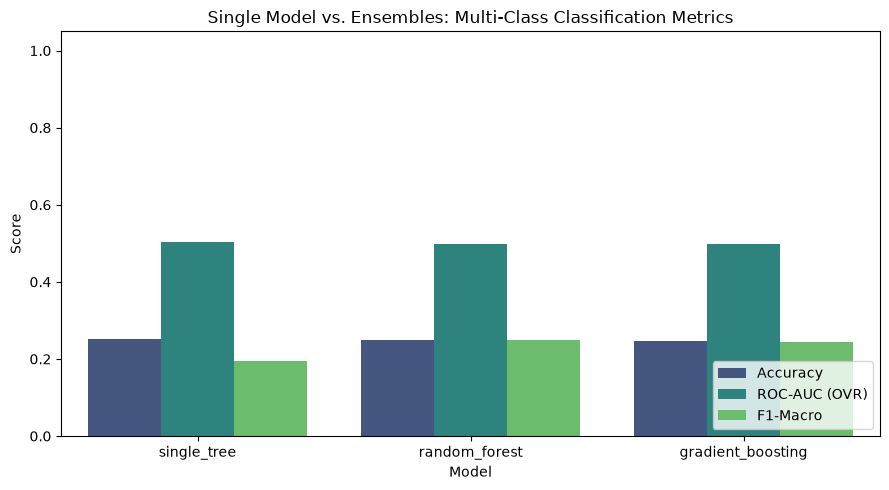

2026-08-02 14:18:30 | INFO | M05 | Best model: single_tree with ROC-AUC = 0.503


In [20]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of them trained on.
For a multi-class target like 'Weather Condition', multi-class ROC-AUC (OVR) 
and macro F1-Score give a complete evaluation picture across all categories.
"""

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Store predictions and full class prediction probabilities
preds = {
    "single_tree": modelA.predict(X_test),
    "random_forest": modelB.predict(X_test),
    "gradient_boosting": modelC.predict(X_test),
}

probs = {
    "single_tree": modelA.predict_proba(X_test),
    "random_forest": modelB.predict_proba(X_test),
    "gradient_boosting": modelC.predict_proba(X_test),
}

# Calculate Accuracy, Multi-class ROC-AUC (One-vs-Rest), and Macro F1-Score
scores: dict[str, float] = {}
roc_auc_scores: dict[str, float] = {}
f1_scores: dict[str, float] = {}

for name in preds:
    scores[name] = float(accuracy_score(y_test, preds[name]))
    
    # Calculate macro F1 across all target classes
    f1_scores[name] = float(f1_score(y_test, preds[name], average="macro"))
    
    # Calculate One-vs-Rest multi-class ROC-AUC
    roc_auc_scores[name] = float(
        roc_auc_score(y_test, probs[name], multi_class="ovr", average="macro")
    )

    LOG.info(
        f"  {name:18s} | Acc: {scores[name]:.3f} | "
        f"AUC: {roc_auc_scores[name]:.3f} | F1: {f1_scores[name]:.3f}"
    )

# Prepare DataFrame for multi-metric visualization
df_metrics = pd.DataFrame(
    {
        "Model": list(scores.keys()) * 3,
        "Metric Score": list(scores.values()) + list(roc_auc_scores.values()) + list(f1_scores.values()),
        "Metric": ["Accuracy"] * 3 + ["ROC-AUC (OVR)"] * 3 + ["F1-Macro"] * 3,
    }
)

# Start a new figure
plt.figure(figsize=(9, 5))

# Plot Accuracy, ROC-AUC, and F1-Score side-by-side
sns.barplot(
    data=df_metrics, x="Model", y="Metric Score", hue="Metric", palette="viridis"
)

plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Single Model vs. Ensembles: Multi-Class Classification Metrics")
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

# Identify top model by ROC-AUC score
best: str = max(roc_auc_scores, key=roc_auc_scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with ROC-AUC = {roc_auc_scores[best]:.3f}")

Oh boy it's useless (The model literally performs almost exactly as well as guessing) This is probably because the data is syntehtic for one thing and then second well I literally tried to predict the non-target value so this is a win! I had Gemini whip up a code block for Category to generate the same thing to see its prediction. It is a regression model because the dataset is specifically designed to predict units sold soooooooo that is a continuous variable.

2026-08-02 14:24:38 | INFO | M05 | Preparing data with TARGET = 'Units Sold'
2026-08-02 14:24:38 | INFO | M05 | Target variable: 'Units Sold' (Min: 0, Max: 499)
2026-08-02 14:24:38 | INFO | M05 | Total features after encoding: 20
2026-08-02 14:24:38 | INFO | M05 | Train samples: 58480 | Test samples: 14620
2026-08-02 14:24:38 | INFO | M05 | Fitting Decision Tree, Random Forest, and Gradient Boosting Regressors...



     MODEL PERFORMANCE COMPARISON (Target: Units Sold)      
Single Tree          | R² Score: 0.993 | RMSE (Error): 9.28 units
Random Forest        | R² Score: 0.994 | RMSE (Error): 8.39 units
Gradient Boosting    | R² Score: 0.994 | RMSE (Error): 8.49 units


C:\Users\jacob\AppData\Local\Temp\ipykernel_28608\317565086.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_r2, x="Model", y="R² Score", palette="viridis")


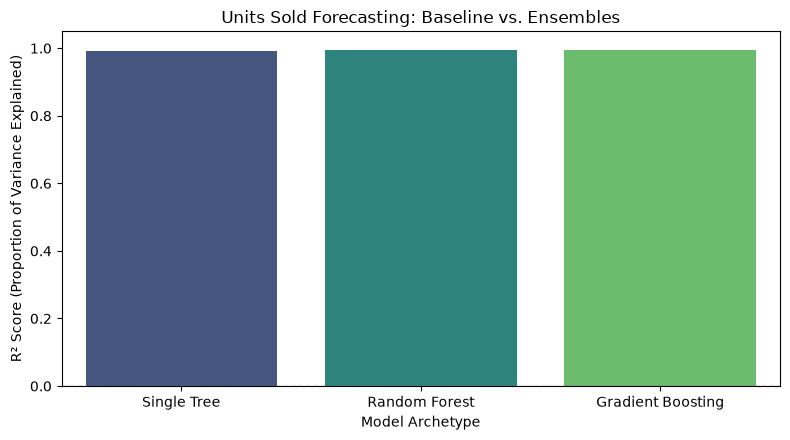

In [22]:
# ==============================================================================
# Complete Pipeline: Predicting 'Units Sold' (Regression Task)
# ==============================================================================

import pandas as pd
import numpy as np
from typing import Final
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE: Final[int] = 42

# ------------------------------------------------------------------------------
# 1. Section 2: Load and Prepare Data
# ------------------------------------------------------------------------------
LOG.info("Preparing data with TARGET = 'Units Sold'")

TARGET_COL: Final[str] = "Units Sold"

# Categorical predictors to one-hot encode
CATEGORICAL_COLS: list[str] = ["Category", "Region", "Seasonality", "Weather Condition"]

# Numerical predictors (excluding Units Sold)
NUMERICAL_COLS: list[str] = [
    "Inventory Level",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing",
]

RAW_FEATURE_COLS: list[str] = CATEGORICAL_COLS + NUMERICAL_COLS

# Drop missing values across required columns
required: list[str] = [TARGET_COL, *RAW_FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

# One-hot encode categorical feature columns
df_model = pd.get_dummies(df_model, columns=CATEGORICAL_COLS, drop_first=True)

# Build feature matrix columns list (excluding ID/Date/Target)
FEATURE_COLS: list[str] = [
    col for col in df_model.columns 
    if col != TARGET_COL and col not in ["Store ID", "Product ID", "Date"]
]

LOG.info(f"Target variable: '{TARGET_COL}' (Min: {df_model[TARGET_COL].min()}, Max: {df_model[TARGET_COL].max()})")
LOG.info(f"Total features after encoding: {len(FEATURE_COLS)}")

# ------------------------------------------------------------------------------
# 2. Section 3: Train / Test Split
# ------------------------------------------------------------------------------
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

# Standard random split for regression (no stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

LOG.info(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# ------------------------------------------------------------------------------
# 3. Section 4: Fit Baseline & Ensemble Regressors
# ------------------------------------------------------------------------------
LOG.info("Fitting Decision Tree, Random Forest, and Gradient Boosting Regressors...")

# Baseline Single Decision Tree
modelA = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)

# Bagging Ensemble: Random Forest
modelB = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=RANDOM_STATE
)
modelB.fit(X_train, y_train)

# Boosting Ensemble: Gradient Boosting
modelC = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=RANDOM_STATE
)
modelC.fit(X_train, y_train)

# ------------------------------------------------------------------------------
# 4. Section 5: Evaluate and Plot Metrics
# ------------------------------------------------------------------------------
preds = {
    "Single Tree": modelA.predict(X_test),
    "Random Forest": modelB.predict(X_test),
    "Gradient Boosting": modelC.predict(X_test),
}

r2_scores: dict[str, float] = {}
rmse_scores: dict[str, float] = {}

print("\n" + "="*60)
print(f"{'MODEL PERFORMANCE COMPARISON (Target: Units Sold)':^60}")
print("="*60)

for name, y_pred in preds.items():
    r2_scores[name] = float(r2_score(y_test, y_pred))
    rmse_scores[name] = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    
    print(f"{name:20s} | R² Score: {r2_scores[name]:.3f} | RMSE (Error): {rmse_scores[name]:.2f} units")

print("="*60)

# Build plotting DataFrame for R² Score
df_r2 = pd.DataFrame(
    {
        "Model": list(r2_scores.keys()),
        "R² Score": list(r2_scores.values()),
    }
)

# Plot R² Comparison Chart
plt.figure(figsize=(8, 4.5))
sns.barplot(data=df_r2, x="Model", y="R² Score", palette="viridis")
plt.ylim(min(0, min(r2_scores.values()) - 0.1), 1.05)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Model Archetype")
plt.ylabel("R² Score (Proportion of Variance Explained)")
plt.title("Units Sold Forecasting: Baseline vs. Ensembles")
plt.tight_layout()
plt.show()

ANYWAYS Moving on to Section 6 to evaluate the original dataset

2026-08-02 14:28:10 | INFO | M05 | Random forest feature importances for Weather Condition (high to low):
2026-08-02 14:28:10 | INFO | M05 |    Demand Forecast                0.9993
2026-08-02 14:28:10 | INFO | M05 |    Inventory Level                0.0003
2026-08-02 14:28:10 | INFO | M05 |    Units Ordered                  0.0001
2026-08-02 14:28:10 | INFO | M05 |    Price                          0.0001
2026-08-02 14:28:10 | INFO | M05 |    Competitor Pricing             0.0001
2026-08-02 14:28:10 | INFO | M05 |    Discount                       0.0000


2026-08-02 14:28:10 | INFO | M05 |    Holiday/Promotion              0.0000
2026-08-02 14:28:10 | INFO | M05 |    Weather Condition_Snowy        0.0000
2026-08-02 14:28:10 | INFO | M05 |    Category_Electronics           0.0000
2026-08-02 14:28:10 | INFO | M05 |    Seasonality_Winter             0.0000
2026-08-02 14:28:10 | INFO | M05 |    Seasonality_Summer             0.0000
2026-08-02 14:28:10 | INFO | M05 |    Category_Furniture             0.0000
2026-08-02 14:28:10 | INFO | M05 |    Weather Condition_Sunny        0.0000
2026-08-02 14:28:10 | INFO | M05 |    Seasonality_Spring             0.0000
2026-08-02 14:28:10 | INFO | M05 |    Weather Condition_Rainy        0.0000
2026-08-02 14:28:10 | INFO | M05 |    Region_West                    0.0000
2026-08-02 14:28:10 | INFO | M05 |    Category_Groceries             0.0000
2026-08-02 14:28:10 | INFO | M05 |    Region_North                   0.0000
2026-08-02 14:28:10 | INFO | M05 |    Category_Toys                  0.0000
2026-08-02 1

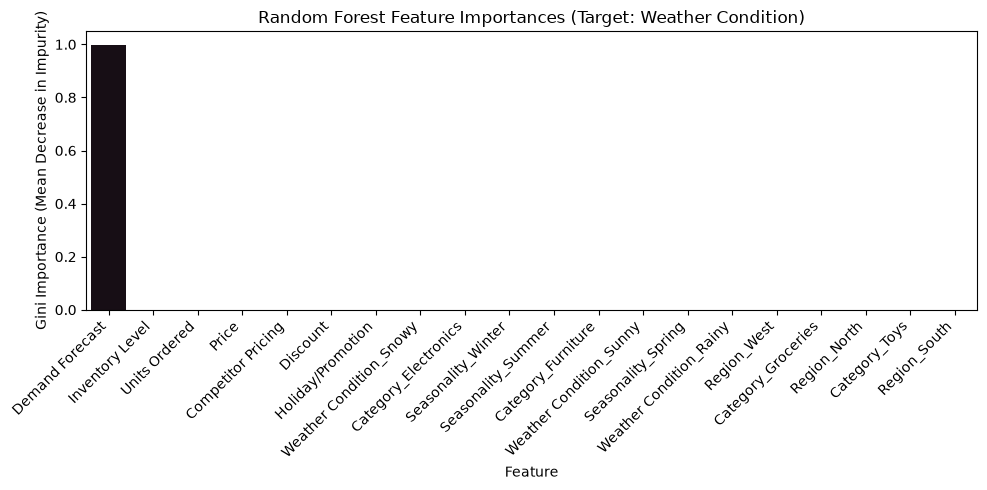

In [25]:
# === Section 6. Feature Importances (Random Forest) ===

"""Chart the random forest's feature importances for Weather Condition.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue, not proof of causation.
Interpret them with the same care as any other finding.
"""

# Explicitly ensure target context
TARGET_COL = "Weather Condition"

# Extract feature importances directly matching current X columns
feature_names: list[str] = list(X.columns)
importances: np.ndarray = modelB.feature_importances_

# Sort indices from highest to lowest importance
order: np.ndarray = np.argsort(importances)[::-1]

LOG.info("Random forest feature importances for Weather Condition (high to low):")
for i in order:
    LOG.info(f"   {feature_names[i]:30s} {importances[i]:.4f}")

# Prepare sorted data for visualization
x_values = [feature_names[i] for i in order]
y_values = importances[order]

# Start a new figure
plt.figure(figsize=(10, 5))

# Plot sorted importances using palette and explicit hue mapping
sns.barplot(x=x_values, y=y_values, hue=x_values, legend=False, palette="mako")

plt.xlabel("Feature")
plt.ylabel("Gini Importance (Mean Decrease in Impurity)")
plt.title(f"Random Forest Feature Importances (Target: {TARGET_COL})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Show the plot
plt.show()

The model relied almost entirely on Demand Forecast (with a Gini importance of ~0.999) to predict Weather Condition. This is a classic example of Target Leakage caused by synthetic dataset design. In the underlying data generator, Demand Forecast was likely derived directly from Weather Condition (e.g., higher forecast for rainy gear on rainy days). When flipping the target to predict weather, the decision tree easily reverse-engineered this mathematical relationship. This stems from improper feature selection during model setup—including a feature that directly encodes information about the target variable.